# EDA — arrets-lignes.csv
Urban Data Explorer · IDFM

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

## 1. Chargement

In [7]:
# ⚠️ Change le chemin si besoin
FILE = 'brute/indicateur-Score-accessibilité-mobilité/arrets-lignes.csv'

df = pd.read_csv(FILE, sep=None, engine='python')
print(f'Shape : {df.shape}')
df.head()

Shape : (73853, 13)


,﻿id,route_long_name,stop_id,stop_name,stop_lon,stop_lat,operatorname,shortname,bookingrules,mode,pointgeo,nom_commune,code_insee
0,IDFM:C01389,T1,IDFM:22259,Jean Rostand,2.454387,48.907847,RATP,T1,NaN,Tramway,"48.90784693451178, 2.454386644826771",Bobigny,93008
1,IDFM:C01389,T1,IDFM:24425,Hôtel de Ville de Bobigny,2.443814,48.906566,RATP,T1,NaN,Tramway,"48.906566265422576, 2.4438136690531236",Bobigny,93008
2,IDFM:C01389,T1,IDFM:22629,La Courneuve - 8 Mai 1945,2.410637,48.920859,RATP,T1,NaN,Tramway,"48.920859363612415, 2.4106374774533097",La Courneuve,93027
3,IDFM:C01389,T1,IDFM:22269,Théâtre Gérard Philipe,2.350332,48.937517,RATP,T1,NaN,Tramway,"48.93751719094905, 2.350332065279392",Saint-Denis,93066
4,IDFM:C01389,T1,IDFM:24431,Gare de Saint-Denis,2.344087,48.935909,RATP,T1,NaN,Tramway,"48.9359094255586, 2.3440867496171425",Saint-Denis,93066


## 2. Infos générales

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73853 entries, 0 to 73852
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ﻿id              73853 non-null  object 
 1   route_long_name  73853 non-null  object 
 2   stop_id          73853 non-null  object 
 3   stop_name        73853 non-null  object 
 4   stop_lon         73853 non-null  float64
 5   stop_lat         73853 non-null  float64
 6   operatorname     73853 non-null  object 
 7   shortname        73853 non-null  object 
 8   bookingrules     2312 non-null   object 
 9   mode             73853 non-null  object 
 10  pointgeo         73853 non-null  object 
 11  nom_commune      73853 non-null  object 
 12  code_insee       73853 non-null  int64  
dtypes: float64(2), int64(1), object(10)
memory usage: 7.3+ MB


In [9]:
df.describe(include='all')

,﻿id,route_long_name,stop_id,stop_name,stop_lon,stop_lat,operatorname,shortname,bookingrules,mode,pointgeo,nom_commune,code_insee
count,73853,73853,73853,73853,73853.000000,73853.000000,73853,73853,2312,73853,73853,73853,73853.000000
unique,2010,1909,35900,13420,NaN,NaN,57,1823,15,9,35819,1336,NaN
top,IDFM:C02060,1,IDFM:19851,Mairie,NaN,NaN,RATP,Soir,"[{""id"": ""booking_rule:IDFM:11"", ""name"": ""sans_...",Bus,"48.95719644161834, 2.8738803484010726",Paris,NaN
freq,219,334,34,1917,NaN,NaN,8580,1242,1204,71811,34,6013,NaN
mean,NaN,NaN,NaN,NaN,2.362223,48.804783,NaN,NaN,NaN,NaN,NaN,NaN,84776.303779
std,NaN,NaN,NaN,NaN,0.325985,0.179681,NaN,NaN,NaN,NaN,NaN,NaN,8428.977492
min,NaN,NaN,NaN,NaN,1.149856,47.961079,NaN,NaN,NaN,NaN,NaN,NaN,2168.000000
25%,NaN,NaN,NaN,NaN,2.161428,48.707479,NaN,NaN,NaN,NaN,NaN,NaN,77390.000000
50%,NaN,NaN,NaN,NaN,2.345244,48.838177,NaN,NaN,NaN,NaN,NaN,NaN,78646.000000
75%,NaN,NaN,NaN,NaN,2.532605,48.932522,NaN,NaN,NaN,NaN,NaN,NaN,93001.000000


## 3. Valeurs manquantes

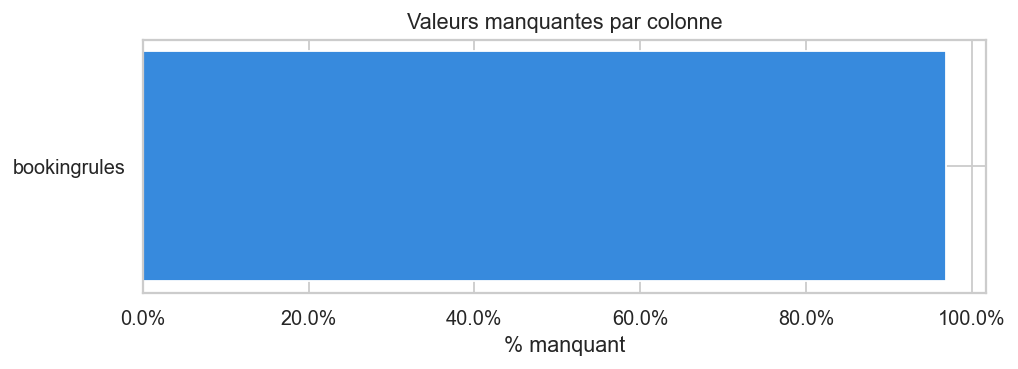

,% manquant
bookingrules,96.869457


In [10]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print('✅ Aucune valeur manquante')
else:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing) * 0.4)))
    ax.barh(missing.index, missing.values, color='#378ADD')
    ax.set_xlabel('% manquant')
    ax.set_title('Valeurs manquantes par colonne')
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
    plt.tight_layout()
    plt.show()
    display(missing.rename('% manquant').to_frame())

## 4. Doublons

In [11]:
n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup} ({n_dup/len(df)*100:.2f}%)')
if n_dup > 0:
    display(df[df.duplicated(keep=False)].head(10))

Doublons : 0 (0.00%)


## 5. Détection des colonnes clés

In [12]:
def find_col(df, *keywords):
    for kw in keywords:
        match = [c for c in df.columns if kw.lower() in c.lower()]
        if match: return match[0]
    return None

col_map = {
    'stop_name'        : find_col(df, 'stop_name', 'nom_arret', 'nom', 'name'),
    'stop_lat'         : find_col(df, 'stop_lat', 'lat'),
    'stop_lon'         : find_col(df, 'stop_lon', 'stop_lng', 'lon', 'lng'),
    'route_type'       : find_col(df, 'route_type', 'mode'),
    'route_short_name' : find_col(df, 'route_short_name', 'ligne', 'line'),
    'route_long_name'  : find_col(df, 'route_long_name'),
}

for k, v in col_map.items():
    status = '✅' if v else '❌'
    print(f'{status}  {k:22s} → {v}')

✅  stop_name              → stop_name
✅  stop_lat               → stop_lat
✅  stop_lon               → stop_lon
✅  route_type             → mode
❌  route_short_name       → None
✅  route_long_name        → route_long_name


## 6. Répartition par mode de transport (route_type)

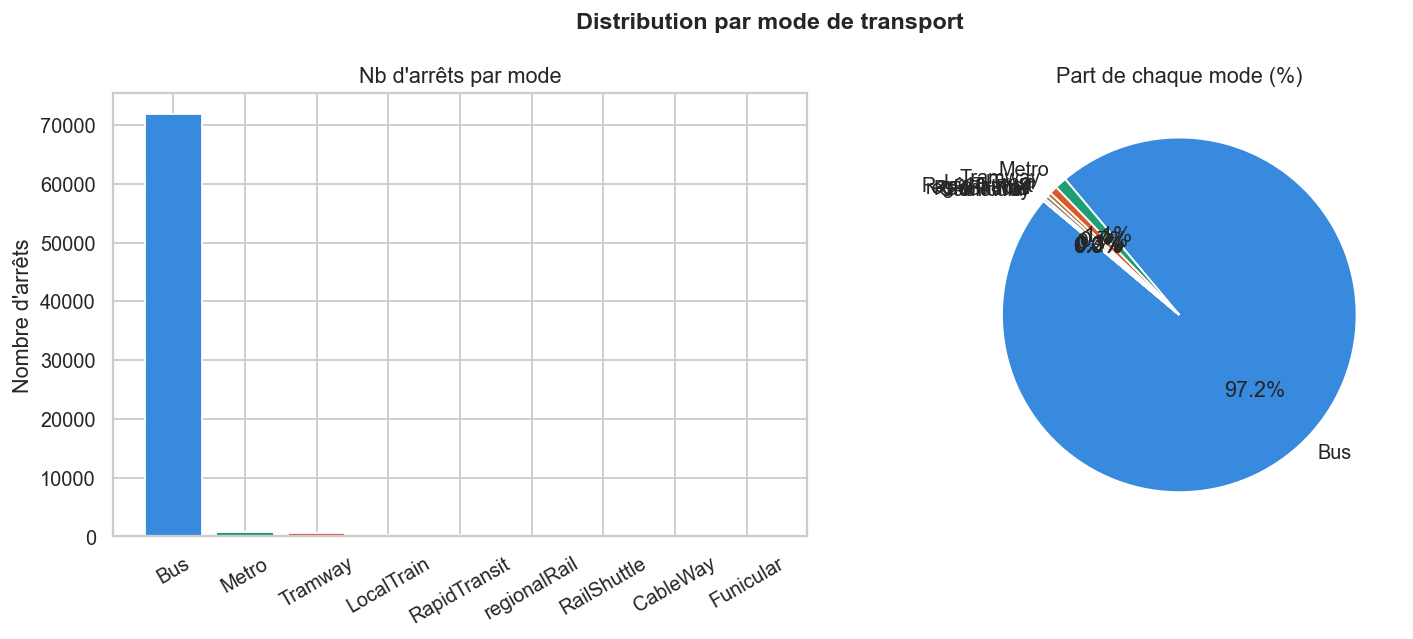

,Mode,Arrêts
0,Bus,71811
1,Metro,805
2,Tramway,541
3,LocalTrain,263
4,RapidTransit,253
5,regionalRail,150
6,RailShuttle,16
7,CableWay,10
8,Funicular,4


In [13]:
ROUTE_LABELS = {
    0: 'Tramway', 1: 'Métro', 2: 'Train/RER',
    3: 'Bus', 4: 'Ferry', 7: 'Funiculaire', 11: 'Trolley'
}

route_col = col_map['route_type']
if route_col:
    vc = df[route_col].value_counts().reset_index()
    vc.columns = ['route_type', 'count']
    vc['label'] = vc['route_type'].apply(
        lambda x: f"{ROUTE_LABELS.get(int(x), str(x))} ({x})" if str(x).isdigit() else str(x)
    )
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    colors = ['#378ADD','#1D9E75','#D85A30','#BA7517','#888780','#534AB7','#D4537E']
    ax1.bar(vc['label'], vc['count'], color=colors[:len(vc)])
    ax1.set_title('Nb d\'arrêts par mode')
    ax1.set_ylabel('Nombre d\'arrêts')
    ax1.tick_params(axis='x', rotation=30)

    ax2.pie(vc['count'], labels=vc['label'], autopct='%1.1f%%',
            colors=colors[:len(vc)], startangle=140)
    ax2.set_title('Part de chaque mode (%)')

    plt.suptitle('Distribution par mode de transport', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    display(vc[['label','count']].rename(columns={'label':'Mode','count':'Arrêts'}))
else:
    print('❌ Colonne route_type non trouvée')

## 7. Top 20 lignes les plus représentées

In [14]:
line_col = col_map['route_short_name']
if line_col:
    top = df[line_col].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top.index.astype(str), top.values, color='#BA7517')
    ax.set_title('Top 20 lignes (nb d\'arrêts desservis)')
    ax.set_xlabel('Nombre d\'arrêts')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print('❌ Colonne route_short_name non trouvée')

❌ Colonne route_short_name non trouvée


## 8. Distribution géographique

Arrêts dans Paris intra-muros (approx) : 28,776
Arrêts en IDF                          : 73,813
Hors IDF                               : 40


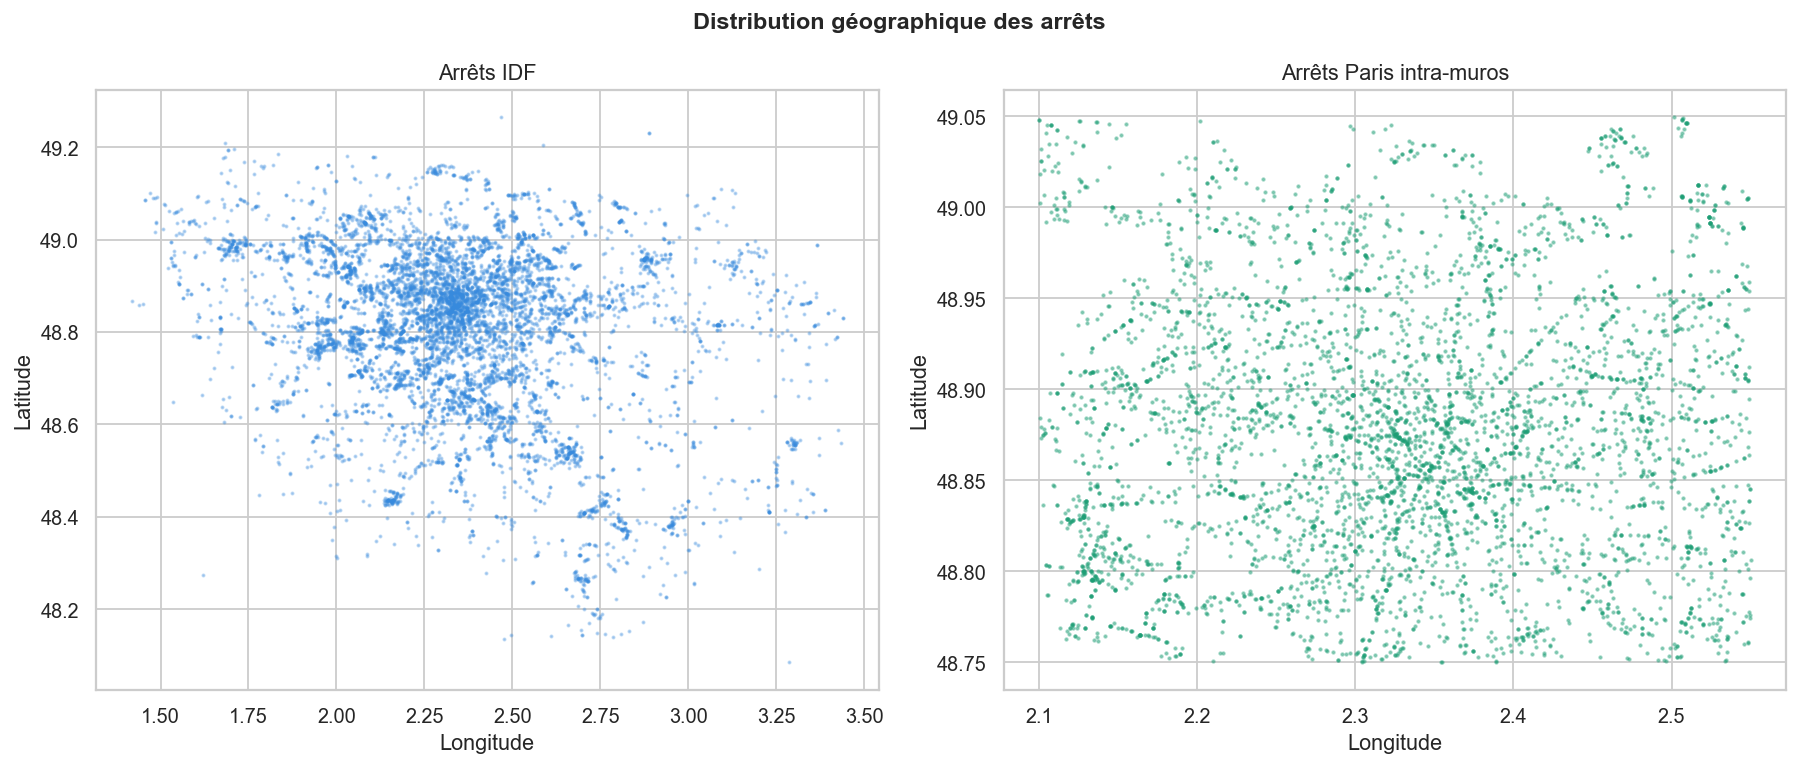

In [15]:
lat_col = col_map['stop_lat']
lon_col = col_map['stop_lon']

if lat_col and lon_col:
    geo = df[[lat_col, lon_col]].dropna()
    # Filtre Paris + IDF (bbox approximative)
    paris = geo[(geo[lat_col].between(48.75, 49.05)) & (geo[lon_col].between(2.1, 2.55))]
    idf   = geo[(geo[lat_col].between(48.0, 49.4))  & (geo[lon_col].between(1.4, 3.6))]

    print(f'Arrêts dans Paris intra-muros (approx) : {len(paris):,}')
    print(f'Arrêts en IDF                          : {len(idf):,}')
    print(f'Hors IDF                               : {len(geo) - len(idf):,}')

    sample = idf.sample(min(8000, len(idf)), random_state=42)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].scatter(sample[lon_col], sample[lat_col], s=1.5, alpha=0.3, color='#378ADD')
    axes[0].set_title('Arrêts IDF')
    axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

    paris_sample = paris.sample(min(5000, len(paris)), random_state=42)
    axes[1].scatter(paris_sample[lon_col], paris_sample[lat_col], s=2, alpha=0.4, color='#1D9E75')
    axes[1].set_title('Arrêts Paris intra-muros')
    axes[1].set_xlabel('Longitude'); axes[1].set_ylabel('Latitude')

    plt.suptitle('Distribution géographique des arrêts', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('❌ Colonnes lat/lon non trouvées')

## 9. Cardinalité des colonnes catégorielles

In [16]:
cat_cols = df.select_dtypes(include='object').columns
cardinality = pd.DataFrame({
    'colonne'     : cat_cols,
    'unique'      : [df[c].nunique() for c in cat_cols],
    'exemple'     : [df[c].dropna().iloc[0] if not df[c].dropna().empty else 'N/A' for c in cat_cols],
    '% manquant'  : [round(df[c].isnull().mean() * 100, 1) for c in cat_cols],
}).sort_values('unique', ascending=False)

display(cardinality)

,colonne,unique,exemple,% manquant
2,stop_id,35900,IDFM:22259,0.0
8,pointgeo,35819,"48.90784693451178, 2.454386644826771",0.0
3,stop_name,13420,Jean Rostand,0.0
0,﻿id,2010,IDFM:C01389,0.0
1,route_long_name,1909,T1,0.0
5,shortname,1823,T1,0.0
9,nom_commune,1336,Bobigny,0.0
4,operatorname,57,RATP,0.0
6,bookingrules,15,"[{""id"": ""booking_rule:IDFM:11"", ""name"": ""sans_...",96.9
7,mode,9,Tramway,0.0


## 10. Résumé final

In [17]:
print('=' * 50)
print('RÉSUMÉ EDA — arrets-lignes.csv')
print('=' * 50)
print(f'  Lignes          : {len(df):,}')
print(f'  Colonnes        : {len(df.columns)}')
print(f'  Doublons        : {df.duplicated().sum()}')
missing_count = (df.isnull().sum() > 0).sum()
print(f'  Cols avec NaN   : {missing_count}')
if lat_col and lon_col:
    print(f'  Lat range       : {df[lat_col].min():.4f} → {df[lat_col].max():.4f}')
    print(f'  Lon range       : {df[lon_col].min():.4f} → {df[lon_col].max():.4f}')
print('=' * 50)

RÉSUMÉ EDA — arrets-lignes.csv
  Lignes          : 73,853
  Colonnes        : 13
  Doublons        : 0
  Cols avec NaN   : 1
  Lat range       : 47.9611 → 49.4593
  Lon range       : 1.1499 → 3.5607
